In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

In [13]:
df = pd.read_csv("website_traffic_data_large.csv")

In [14]:
df.head()

,user_id,session_id,page,timestamp,device,referrer
0,U006,S104,/products,2025-06-05 14:29:00,desktop,direct
1,U002,S060,/contact,2025-06-02 11:52:00,desktop,linkedin.com
2,U014,S029,/about,2025-06-02 03:27:00,desktop,linkedin.com
3,U028,S067,/checkout,2025-06-05 15:11:00,desktop,linkedin.com
4,U047,S055,/products,2025-06-07 17:59:00,mobile,twitter.com


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     400 non-null    object
 1   session_id  400 non-null    object
 2   page        400 non-null    object
 3   timestamp   400 non-null    object
 4   device      400 non-null    object
 5   referrer    400 non-null    object
dtypes: object(6)
memory usage: 18.9+ KB


# Data Collection & Preprocessing


In [23]:


# Load the dataset
df = pd.read_csv("website_traffic_data_large.csv", parse_dates=["timestamp"])
df.sort_values(by=["session_id", "timestamp"], inplace=True)
df.head()


,user_id,session_id,page,timestamp,device,referrer
305,U040,S001,/about,2025-06-01 23:50:00,desktop,direct
36,U018,S001,/home,2025-06-05 09:54:00,tablet,google.com
15,U005,S001,/blog,2025-06-07 05:54:00,mobile,linkedin.com
79,U005,S002,/checkout,2025-06-05 06:44:00,tablet,twitter.com
54,U048,S003,/contact,2025-06-01 15:36:00,tablet,linkedin.com


# Basic Summary

In [6]:
print("Total Records:", len(df))
print("Unique Users:", df["user_id"].nunique())
print("Unique Sessions:", df["session_id"].nunique())
print("Pages:", df["page"].nunique())
print("Time Range:", df["timestamp"].min(), "to", df["timestamp"].max())


Total Records: 400
Unique Users: 50
Unique Sessions: 144
Pages: 6
Time Range: 2025-06-01 08:24:00 to 2025-06-08 05:42:00


# Identify Popular Pages

In [17]:
# Count how many times each page was visited
popular_pages = df['page'].value_counts()
print("Most Visited Pages:")
print(popular_pages)


Most Visited Pages:
page
/blog        77
/checkout    75
/home        65
/contact     62
/products    61
/about       60
Name: count, dtype: int64


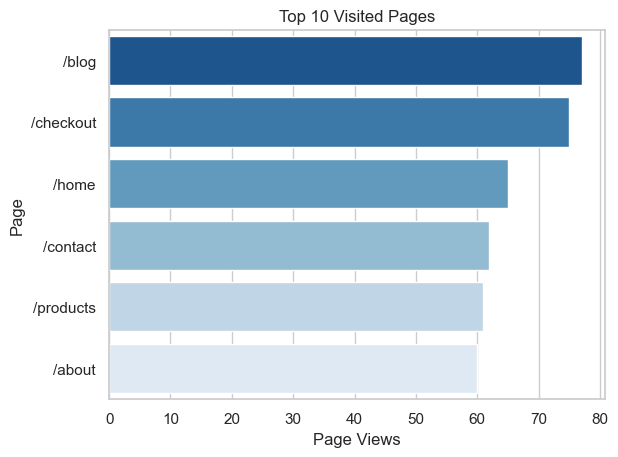

In [21]:


popular_pages = df["page"].value_counts()
sns.barplot(x=popular_pages.values[:10], y=popular_pages.index[:10], palette="Blues_r")
plt.title("Top 10 Visited Pages")
plt.xlabel("Page Views")
plt.ylabel("Page")
plt.show()




# Entry Points & Exit Points


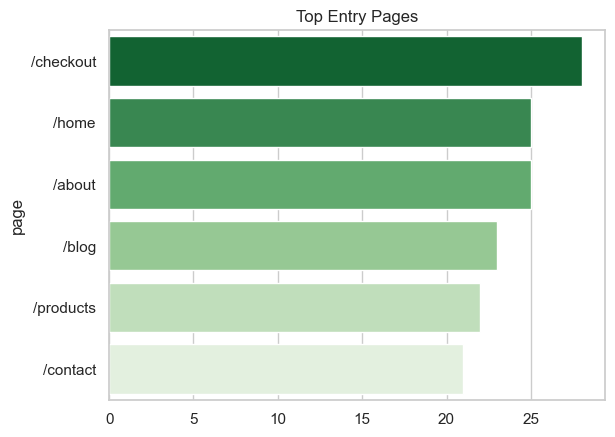

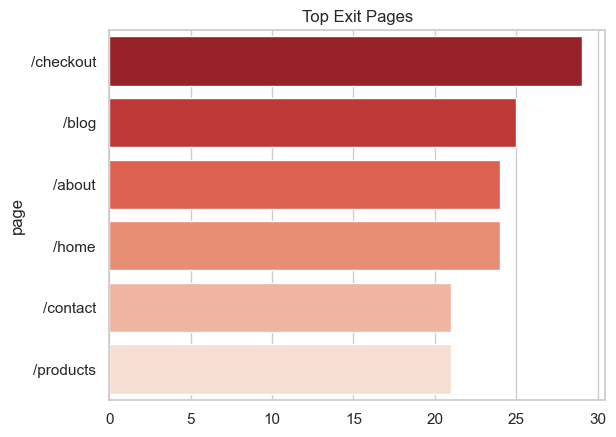

In [22]:
entry_pages = df.groupby("session_id").first()["page"].value_counts()
exit_pages = df.groupby("session_id").last()["page"].value_counts()

# Entry
sns.barplot(x=entry_pages.values[:10], y=entry_pages.index[:10], palette="Greens_r")
plt.title("Top Entry Pages")
plt.show()

# Exit
sns.barplot(x=exit_pages.values[:10], y=exit_pages.index[:10], palette="Reds_r")
plt.title("Top Exit Pages")
plt.show()


# User Navigation Patterns (Path Flow)

In [36]:
paths = df.groupby("session_id")["page"].apply(lambda x: " → ".join(x)).reset_index()
paths.columns = ['session_id', 'navigation_path']
print(paths.head())


  session_id                                    navigation_path
0       S001                             /blog → /home → /about
1       S002                                          /checkout
2       S003                                           /contact
3       S004  /home → /about → /contact → /contact → /home →...
4       S005                   /checkout → /checkout → /contact


# Page Views and Bounce Rate Calculation

In [37]:
session_page_counts = df.groupby("session_id")["page"].count()
bounces = session_page_counts[session_page_counts == 1].count()
bounce_rate = (bounces / df["session_id"].nunique()) * 100
print(f"Bounce Rate: {bounce_rate:.2f}%")



Bounce Rate: 21.53%


 # Time Analysis 

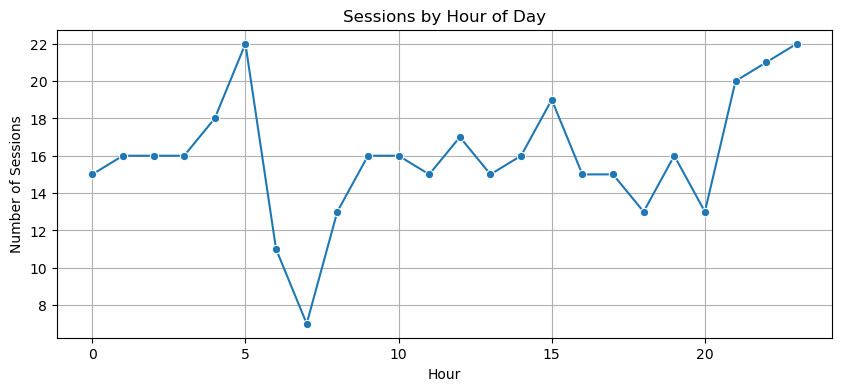

In [24]:
df['hour'] = df['timestamp'].dt.hour
hourly_sessions = df.groupby('hour')['session_id'].nunique()

plt.figure(figsize=(10,4))
sns.lineplot(x=hourly_sessions.index, y=hourly_sessions.values, marker='o')
plt.title("Sessions by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Sessions")
plt.grid(True)
plt.show()


# Device Usage

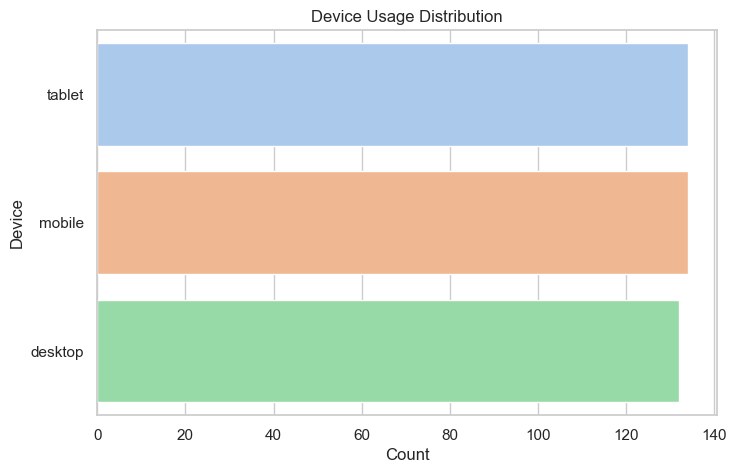

In [11]:
device_counts = df['device'].value_counts()
plt.figure(figsize=(8,5))
sns.barplot(x=device_counts.values, y=device_counts.index, palette="pastel")
plt.title("Device Usage Distribution")
plt.xlabel("Count")
plt.ylabel("Device")
plt.show()


# Referrer Source

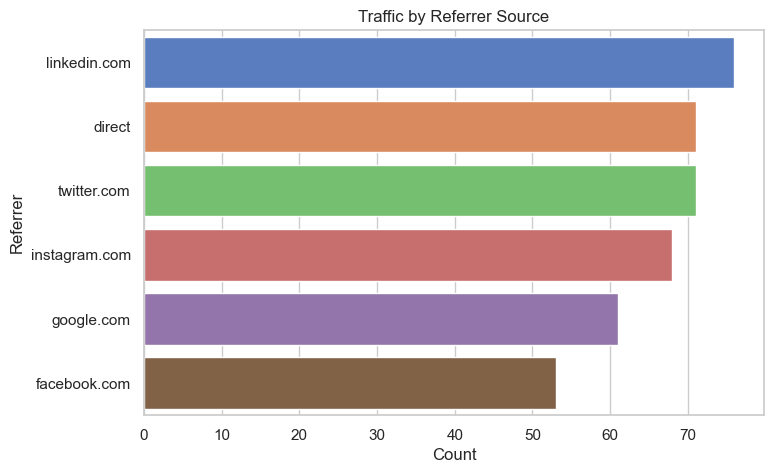

In [12]:
referrer_counts = df['referrer'].value_counts()
plt.figure(figsize=(8,5))
sns.barplot(x=referrer_counts.values, y=referrer_counts.index, palette="muted")
plt.title("Traffic by Referrer Source")
plt.xlabel("Count")
plt.ylabel("Referrer")
plt.show()


# Average Pages per Session



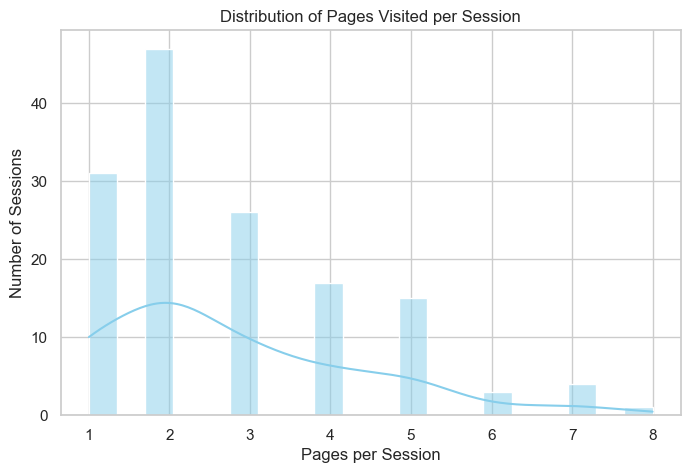

In [13]:
session_pages = df.groupby("session_id")["page"].count()
plt.figure(figsize=(8,5))
sns.histplot(session_pages, bins=20, kde=True, color="skyblue")
plt.title("Distribution of Pages Visited per Session")
plt.xlabel("Pages per Session")
plt.ylabel("Number of Sessions")
plt.show()


# Session Lengths Over Time

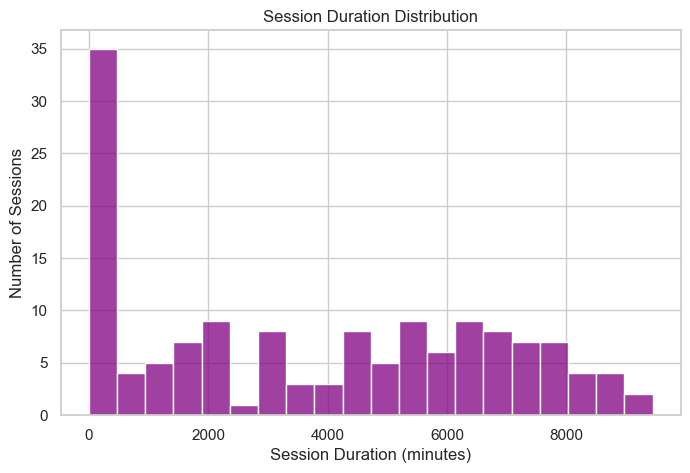

In [14]:
session_times = df.groupby("session_id")["timestamp"].agg(["min", "max"])
session_times["duration_minutes"] = (session_times["max"] - session_times["min"]).dt.total_seconds() / 60

plt.figure(figsize=(8,5))
sns.histplot(session_times["duration_minutes"], bins=20, color="purple")
plt.title("Session Duration Distribution")
plt.xlabel("Session Duration (minutes)")
plt.ylabel("Number of Sessions")
plt.show()


 # Heatmap: Pages vs Hour of Day

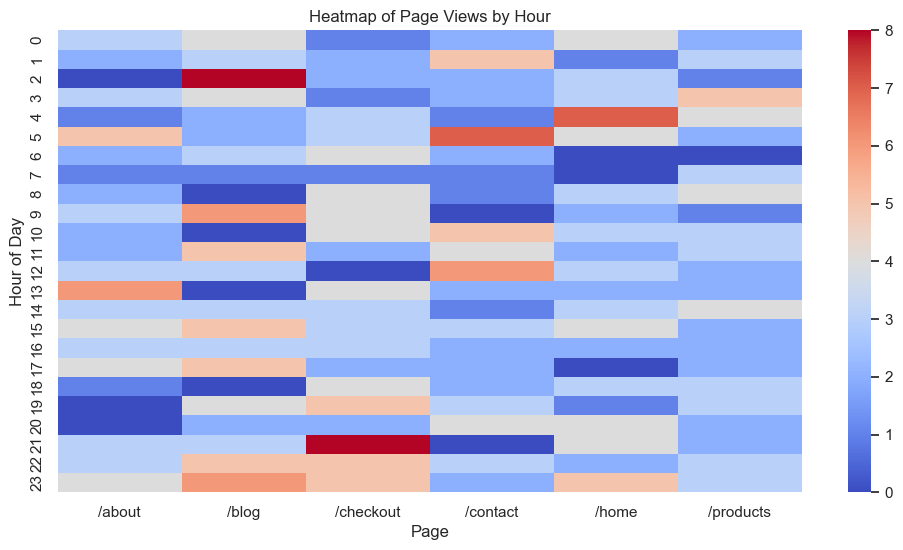

In [18]:
df["hour"] = df["timestamp"].dt.hour
heatmap_data = df.groupby(["hour", "page"]).size().unstack(fill_value=0)

plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, cmap="coolwarm")
plt.title("Heatmap of Page Views by Hour")
plt.xlabel("Page")
plt.ylabel("Hour of Day")
plt.show()

